# 🎯 Notebook 03: Customer Segmentation – K-Means + PCA

**Đồ án:** Xây dựng hệ thống E-commerce tích hợp Machine Learning

**Mục tiêu:** Tự động phân nhóm khách hàng thành 3-4 segments dựa trên hành vi mua sắm (RFM).

**Thuật toán:**
- PCA (Principal Component Analysis) – Giảm chiều dữ liệu
- K-Means Clustering – Phân cụm khách hàng

**Notebook này thực hiện:**
1. Load dữ liệu RFM từ Notebook 01
2. Chuẩn hóa features với StandardScaler
3. PCA: Giảm chiều + phân tích Explained Variance
4. Tìm số cụm tối ưu (Elbow + Silhouette)
5. K-Means Clustering
6. Trực quan hóa & phân tích ý nghĩa từng cụm
7. Export models + segment labels

---

> ⚠️ **Yêu cầu:** Chạy Notebook 01 trước để tạo `customer_features.csv`.

## 0. Setup & Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('✅ Import thành công!')

✅ Import thành công!


In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/ecommerce-ml'
DATA_DIR = f'{PROJECT_DIR}/data'
MODEL_DIR = f'{PROJECT_DIR}/models'

Mounted at /content/drive


## 1. Load dữ liệu

In [3]:
# Load customer features từ Notebook 01
customer_data = pd.read_csv(f'{DATA_DIR}/customer_features.csv')

print(f'✅ Loaded: {customer_data.shape}')
customer_data.head()

✅ Loaded: (5023, 19)


,Customer ID,last_purchase_date,first_purchase_date,frequency,monetary,total_items,total_unique_products,avg_unit_price,country,recency,days_since_first_purchase,avg_order_value,avg_items_per_order,avg_days_between_orders,is_weekend_shopper,favorite_hour,cancellation_rate,country_encoded,will_purchase
0,12346,2011-01-18 10:01:00,2009-12-14 08:34:00,12,77556.46,74285,27,6.100000,United Kingdom,162,562,6463.038333,6190.416667,57.142857,0.000000,13,0.8235,38,0
1,12347,2011-06-09 13:01:00,2010-10-31 14:20:00,5,3529.27,2141,101,2.552717,Iceland,20,241,705.854000,428.200000,55.250000,0.231214,14,0.0000,16,1
2,12348,2011-04-05 10:47:00,2010-09-27 14:59:00,4,1388.40,2488,24,0.672727,Finland,85,275,347.100000,622.000000,63.333333,0.000000,14,0.0000,12,1
3,12349,2010-10-28 08:23:00,2010-04-29 13:20:00,2,2221.14,991,89,4.253400,Italy,244,426,1110.570000,495.500000,182.000000,0.000000,8,1.0000,18,1
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,294.40,196,16,1.581250,Norway,147,147,294.400000,196.000000,0.000000,0.000000,16,0.0000,26,0


In [4]:
# Chọn RFM features cho segmentation
# Dùng các features phản ánh hành vi mua sắm tổng thể
RFM_FEATURES = [
    'recency',
    'frequency',
    'monetary',
    'avg_order_value',
    'total_unique_products',
    'avg_days_between_orders',
    'days_since_first_purchase',
]

X_rfm = customer_data[RFM_FEATURES].copy()

# Xử lý NaN/Inf
X_rfm = X_rfm.replace([np.inf, -np.inf], np.nan).fillna(0)

print(f'📊 RFM Features: {X_rfm.shape}')
X_rfm.describe()

📊 RFM Features: (5023, 7)


,recency,frequency,monetary,avg_order_value,total_unique_products,avg_days_between_orders,days_since_first_purchase
count,5023.000000,5023.000000,5023.000000,5023.000000,5023.000000,5023.000000,5023.000000
mean,178.137169,5.360542,2501.672150,377.383265,71.530559,63.163341,378.252638
std,151.792197,10.312308,11395.206761,552.876235,99.833036,77.085634,162.002543
min,0.000000,1.000000,2.900000,2.900000,1.000000,0.000000,0.000000
25%,42.000000,1.000000,317.355000,180.566667,17.000000,0.000000,254.000000
50%,146.000000,3.000000,778.830000,284.850000,40.000000,42.333333,415.000000
75%,265.500000,6.000000,2018.640000,419.851111,88.000000,92.450000,519.000000
max,575.000000,253.000000,455765.900000,14844.766667,2050.000000,540.000000,575.000000


## 2. Chuẩn hóa dữ liệu (StandardScaler)

K-Means nhạy cảm với scale → bắt buộc phải chuẩn hóa. PCA cũng cần dữ liệu đã scale.

In [5]:
scaler_seg = StandardScaler()
X_scaled = scaler_seg.fit_transform(X_rfm)

print(f'✅ Scaled shape: {X_scaled.shape}')
print(f'   Mean ≈ 0: {X_scaled.mean():.6f}')
print(f'   Std  ≈ 1: {X_scaled.std():.6f}')

✅ Scaled shape: (5023, 7)
   Mean ≈ 0: -0.000000
   Std  ≈ 1: 1.000000


## 3. PCA – Giảm chiều dữ liệu

Giảm từ 7 features → 2-3 thành phần chính, vừa giúp:
- Loại bỏ nhiễu
- Visualize được trên 2D
- K-Means hoạt động tốt hơn trên không gian thấp chiều

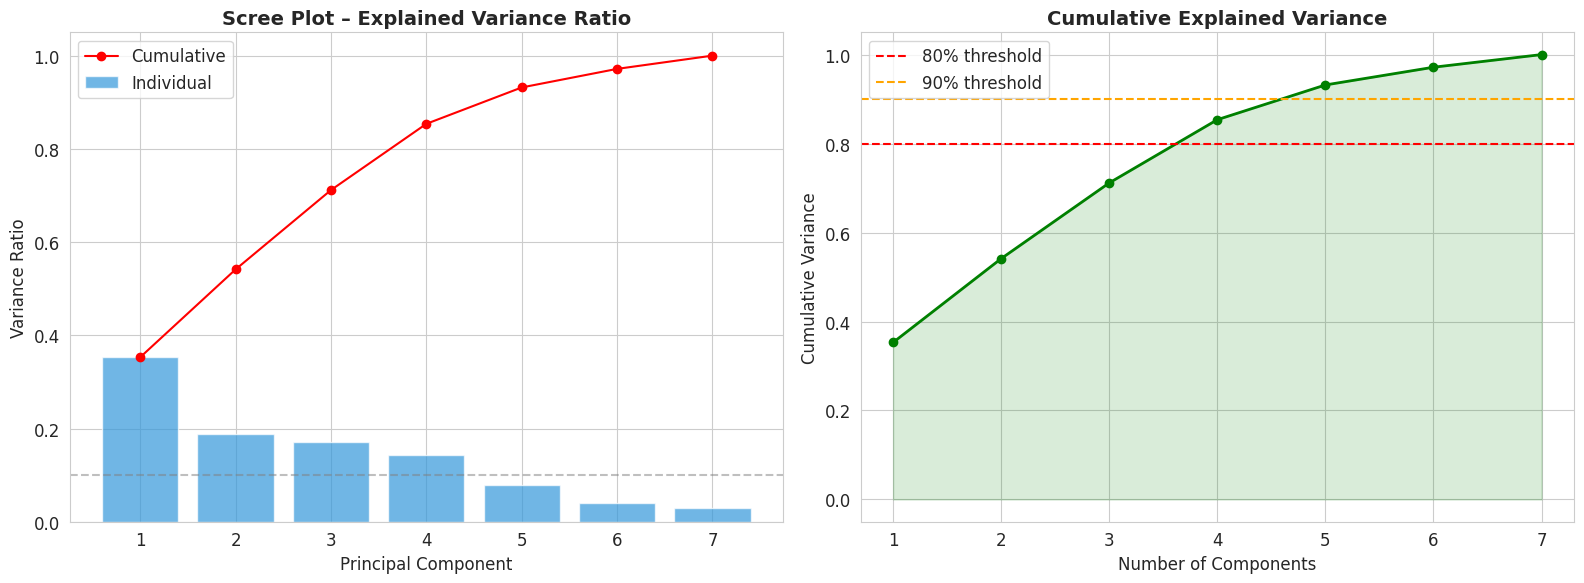


📊 Explained Variance per Component:
  PC1: 0.3529 (35.3%) | Cumulative: 0.3529 (35.3%) █████████████████
  PC2: 0.1884 (18.8%) | Cumulative: 0.5414 (54.1%) █████████
  PC3: 0.1702 (17.0%) | Cumulative: 0.7116 (71.2%) ████████
  PC4: 0.1421 (14.2%) | Cumulative: 0.8537 (85.4%) ███████
  PC5: 0.0781 (7.8%) | Cumulative: 0.9317 (93.2%) ███
  PC6: 0.0399 (4.0%) | Cumulative: 0.9716 (97.2%) █
  PC7: 0.0284 (2.8%) | Cumulative: 1.0000 (100.0%) █


In [6]:
# Fit PCA trên tất cả components trước để xem Explained Variance
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

# Scree Plot (Explained Variance)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Individual
explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

axes[0].bar(range(1, len(explained_var)+1), explained_var, alpha=0.7,
             color='#3498db', label='Individual')
axes[0].plot(range(1, len(cumulative_var)+1), cumulative_var, 'ro-',
              label='Cumulative')
axes[0].axhline(y=0.1, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('Scree Plot – Explained Variance Ratio', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Ratio')
axes[0].set_xticks(range(1, len(explained_var)+1))
axes[0].legend()

# Cumulative
axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var, 'go-', linewidth=2)
axes[1].fill_between(range(1, len(cumulative_var)+1), cumulative_var, alpha=0.15, color='green')
axes[1].axhline(y=0.80, color='red', linestyle='--', label='80% threshold')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90% threshold')
axes[1].set_title('Cumulative Explained Variance', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance')
axes[1].set_xticks(range(1, len(cumulative_var)+1))
axes[1].legend()

plt.tight_layout()
plt.show()

# In chi tiết
print('\n📊 Explained Variance per Component:')
for i, (var, cum) in enumerate(zip(explained_var, cumulative_var), 1):
    bar = '█' * int(var * 50)
    print(f'  PC{i}: {var:.4f} ({var*100:.1f}%) | Cumulative: {cum:.4f} ({cum*100:.1f}%) {bar}')

✅ PCA với 3 components
   Total explained variance: 0.7116 (71.2%)

📊 Component Loadings (feature contribution to each PC):
                             PC1    PC2    PC3
recency                   -0.259  0.092  0.791
frequency                  0.565 -0.054  0.056
monetary                   0.483 -0.211  0.171
avg_order_value            0.199 -0.273  0.144
total_unique_products      0.526  0.024 -0.034
avg_days_between_orders    0.057  0.673 -0.387
days_since_first_purchase  0.247  0.645  0.413


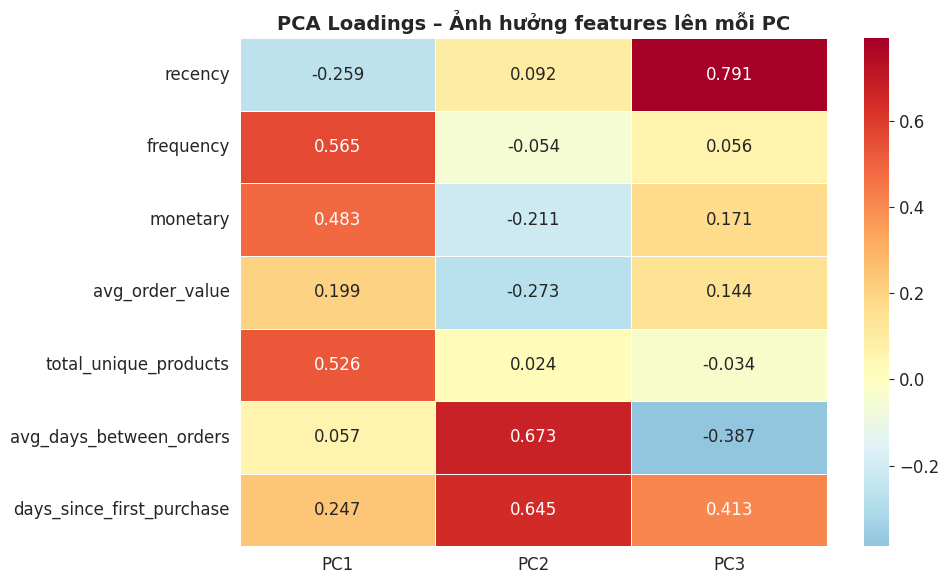

In [7]:
# Chọn số components sao cho >= 80% variance
# Dùng 3 components cho modeling, 2 components cho visualization

N_COMPONENTS = 3

pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled)

total_var = sum(pca.explained_variance_ratio_)
print(f'✅ PCA với {N_COMPONENTS} components')
print(f'   Total explained variance: {total_var:.4f} ({total_var*100:.1f}%)')

# Component loadings (ảnh hưởng của mỗi feature lên mỗi PC)
loadings = pd.DataFrame(
    pca.components_.T,
    index=RFM_FEATURES,
    columns=[f'PC{i+1}' for i in range(N_COMPONENTS)]
)

print('\n📊 Component Loadings (feature contribution to each PC):')
print(loadings.round(3).to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(loadings, annot=True, fmt='.3f', cmap='RdYlBu_r', center=0,
            ax=ax, linewidths=0.5)
ax.set_title('PCA Loadings – Ảnh hưởng features lên mỗi PC', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Tìm số cụm tối ưu (Optimal K)

Sử dụng 2 phương pháp:
- **Elbow Method**: Tìm điểm "khuỷu tay" trên đồ thị Inertia vs K
- **Silhouette Score**: Đo mức độ tách biệt giữa các cụm (càng cao càng tốt)

🔍 Tìm số cụm tối ưu...
  K=2: Inertia=18,771 | Silhouette=0.3301 | Davies-Bouldin=1.2692
  K=3: Inertia=13,796 | Silhouette=0.3385 | Davies-Bouldin=0.9757
  K=4: Inertia=10,052 | Silhouette=0.3740 | Davies-Bouldin=0.8120
  K=5: Inertia=7,545 | Silhouette=0.3946 | Davies-Bouldin=0.7945
  K=6: Inertia=6,469 | Silhouette=0.3728 | Davies-Bouldin=0.8595
  K=7: Inertia=5,536 | Silhouette=0.3678 | Davies-Bouldin=0.8629
  K=8: Inertia=4,752 | Silhouette=0.3728 | Davies-Bouldin=0.8468


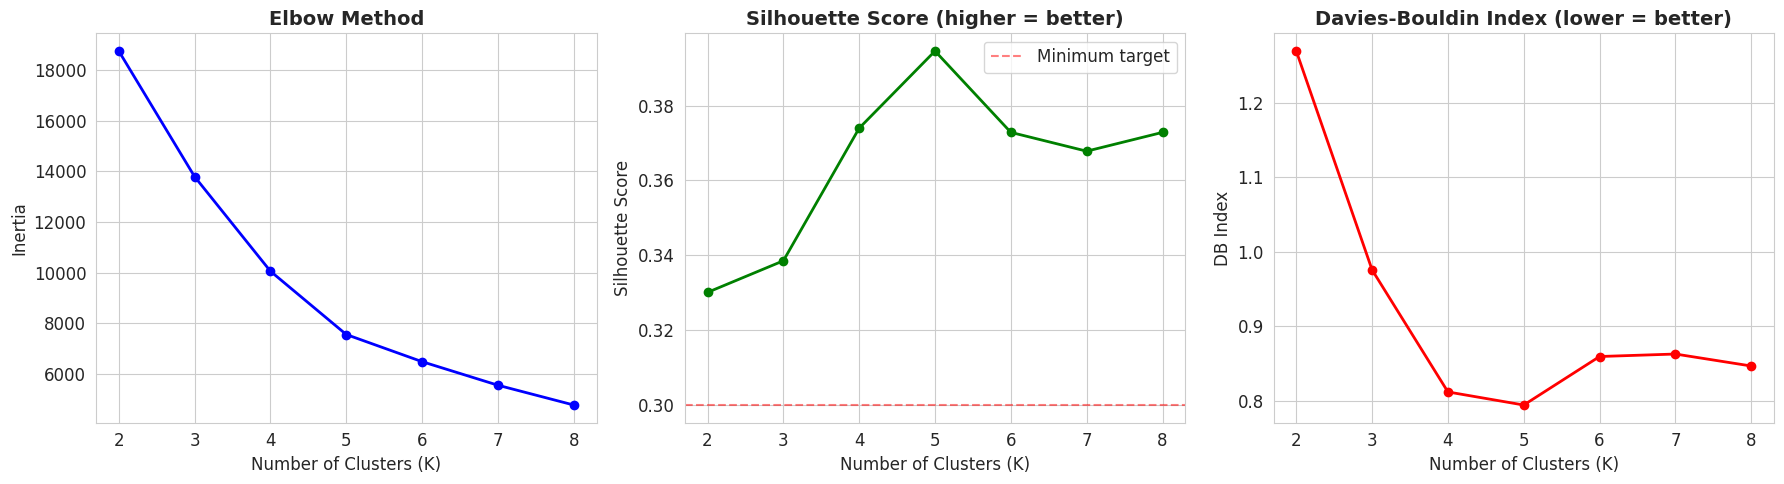


🏆 Best K by Silhouette: 5 (Score: 0.3946)


In [8]:
# Thử K từ 2 đến 8
K_RANGE = range(2, 9)
inertias = []
silhouette_scores = []
db_scores = []

print('🔍 Tìm số cụm tối ưu...')
for k in K_RANGE:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = kmeans.fit_predict(X_pca)

    inertias.append(kmeans.inertia_)
    sil = silhouette_score(X_pca, labels)
    db = davies_bouldin_score(X_pca, labels)
    silhouette_scores.append(sil)
    db_scores.append(db)

    print(f'  K={k}: Inertia={kmeans.inertia_:,.0f} | Silhouette={sil:.4f} | Davies-Bouldin={db:.4f}')

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Elbow
axes[0].plot(list(K_RANGE), inertias, 'bo-', linewidth=2)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(K_RANGE))

# Silhouette
axes[1].plot(list(K_RANGE), silhouette_scores, 'go-', linewidth=2)
axes[1].set_title('Silhouette Score (higher = better)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_RANGE))
axes[1].axhline(y=0.3, color='red', linestyle='--', alpha=0.5, label='Minimum target')
axes[1].legend()

# Davies-Bouldin
axes[2].plot(list(K_RANGE), db_scores, 'ro-', linewidth=2)
axes[2].set_title('Davies-Bouldin Index (lower = better)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Number of Clusters (K)')
axes[2].set_ylabel('DB Index')
axes[2].set_xticks(list(K_RANGE))

plt.tight_layout()
plt.show()

# Recommendation
best_k = list(K_RANGE)[np.argmax(silhouette_scores)]
print(f'\n🏆 Best K by Silhouette: {best_k} (Score: {max(silhouette_scores):.4f})')

In [9]:
# Chọn K (dùng 4 clusters theo plan, hoặc best_k từ trên)
# Bạn có thể thay đổi OPTIMAL_K nếu kết quả Silhouette suggest K khác
OPTIMAL_K = 4  # VIP, Tiềm năng, Vãng lai, Ngủ đông

# Nếu best_k từ Silhouette khác 4, in cảnh báo
if best_k != OPTIMAL_K:
    print(f'⚠️ Silhouette gợi ý K={best_k}, nhưng dùng K={OPTIMAL_K} theo business logic.')
    print(f'   Bạn có thể thay OPTIMAL_K = {best_k} nếu muốn.')
else:
    print(f'✅ K={OPTIMAL_K} phù hợp cả Silhouette lẫn business logic!')

print(f'\n🎯 Sử dụng K = {OPTIMAL_K}')

⚠️ Silhouette gợi ý K=5, nhưng dùng K=4 theo business logic.
   Bạn có thể thay OPTIMAL_K = 5 nếu muốn.

🎯 Sử dụng K = 4


## 5. K-Means Clustering

In [10]:
# Fit K-Means final
kmeans_final = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=42,
    n_init=20,      # Nhiều lần init để ổn định
    max_iter=500
)

cluster_labels = kmeans_final.fit_predict(X_pca)
customer_data['segment_id'] = cluster_labels

# Metrics
sil_final = silhouette_score(X_pca, cluster_labels)
db_final = davies_bouldin_score(X_pca, cluster_labels)

print('=' * 60)
print(f'✅ K-MEANS CLUSTERING (K={OPTIMAL_K})')
print('=' * 60)
print(f'  Silhouette Score:    {sil_final:.4f}')
print(f'  Davies-Bouldin:      {db_final:.4f}')
print(f'  Inertia:             {kmeans_final.inertia_:,.0f}')
print(f'\n📊 Cluster Distribution:')
for i in range(OPTIMAL_K):
    count = (cluster_labels == i).sum()
    pct = count / len(cluster_labels) * 100
    bar = '█' * int(pct / 2)
    print(f'  Cluster {i}: {count:5,} ({pct:5.1f}%) {bar}')

✅ K-MEANS CLUSTERING (K=4)
  Silhouette Score:    0.3740
  Davies-Bouldin:      0.8120
  Inertia:             10,052

📊 Cluster Distribution:
  Cluster 0: 1,069 ( 21.3%) ██████████
  Cluster 1: 1,702 ( 33.9%) ████████████████
  Cluster 2: 2,237 ( 44.5%) ██████████████████████
  Cluster 3:    15 (  0.3%) 


### 5.1. Trực quan hóa Clusters (2D PCA Space)

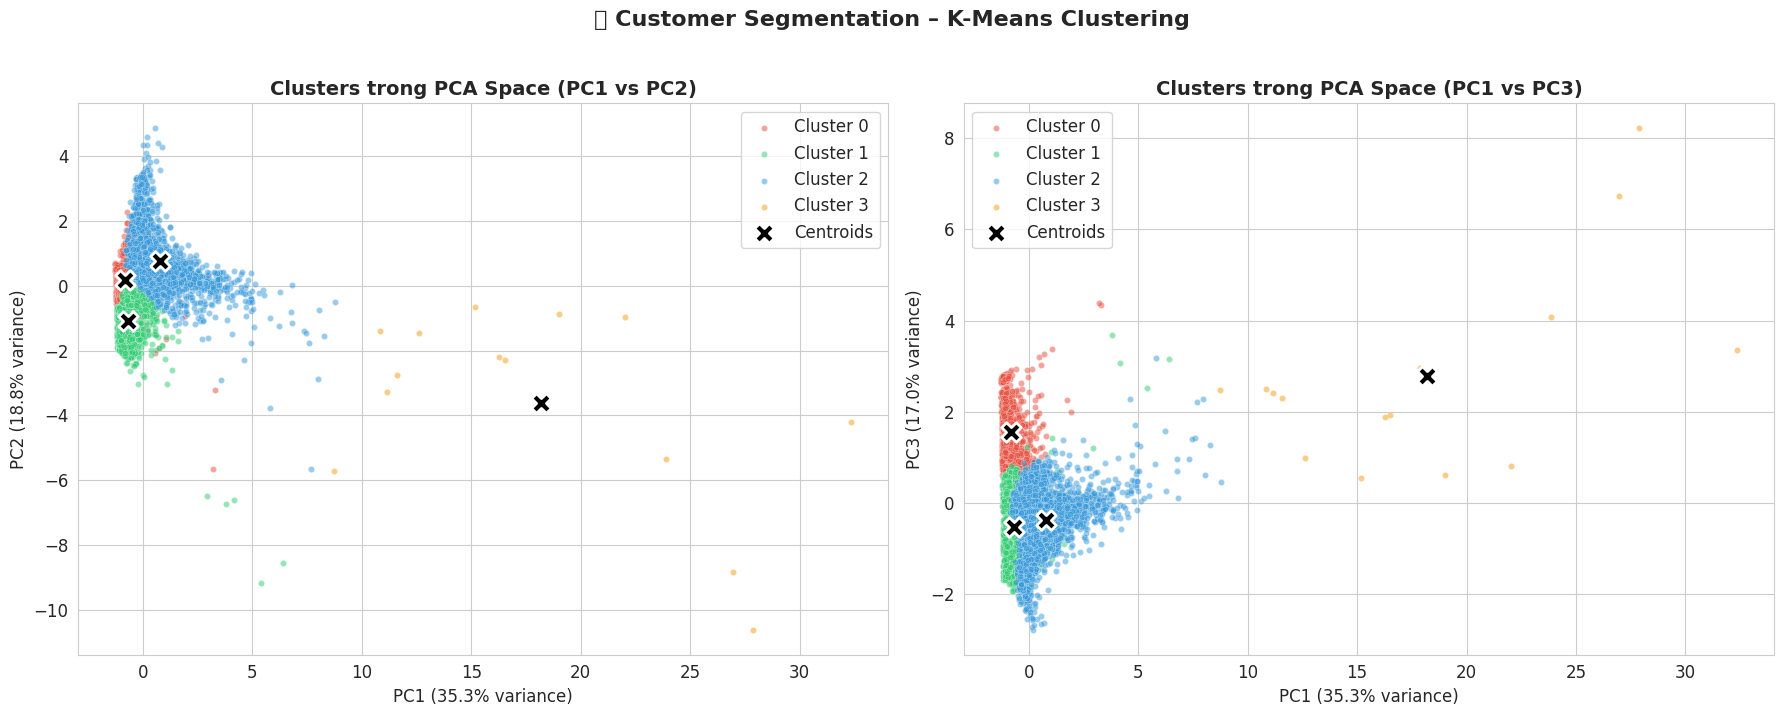

In [11]:
# Scatter plot trong PCA 2D space
cluster_colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6', '#1abc9c']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# PC1 vs PC2
for i in range(OPTIMAL_K):
    mask = cluster_labels == i
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                     c=cluster_colors[i], label=f'Cluster {i}',
                     alpha=0.5, s=20, edgecolors='white', linewidths=0.3)

# Plot centroids
centroids = kmeans_final.cluster_centers_
axes[0].scatter(centroids[:, 0], centroids[:, 1],
                 c='black', marker='X', s=200, edgecolors='white', linewidths=2,
                 label='Centroids', zorder=5)

axes[0].set_title('Clusters trong PCA Space (PC1 vs PC2)', fontsize=14, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].legend()

# PC1 vs PC3
for i in range(OPTIMAL_K):
    mask = cluster_labels == i
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 2],
                     c=cluster_colors[i], label=f'Cluster {i}',
                     alpha=0.5, s=20, edgecolors='white', linewidths=0.3)

axes[1].scatter(centroids[:, 0], centroids[:, 2],
                 c='black', marker='X', s=200, edgecolors='white', linewidths=2,
                 label='Centroids', zorder=5)

axes[1].set_title('Clusters trong PCA Space (PC1 vs PC3)', fontsize=14, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}% variance)')
axes[1].legend()

plt.suptitle('🎯 Customer Segmentation – K-Means Clustering', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.2. Silhouette Analysis

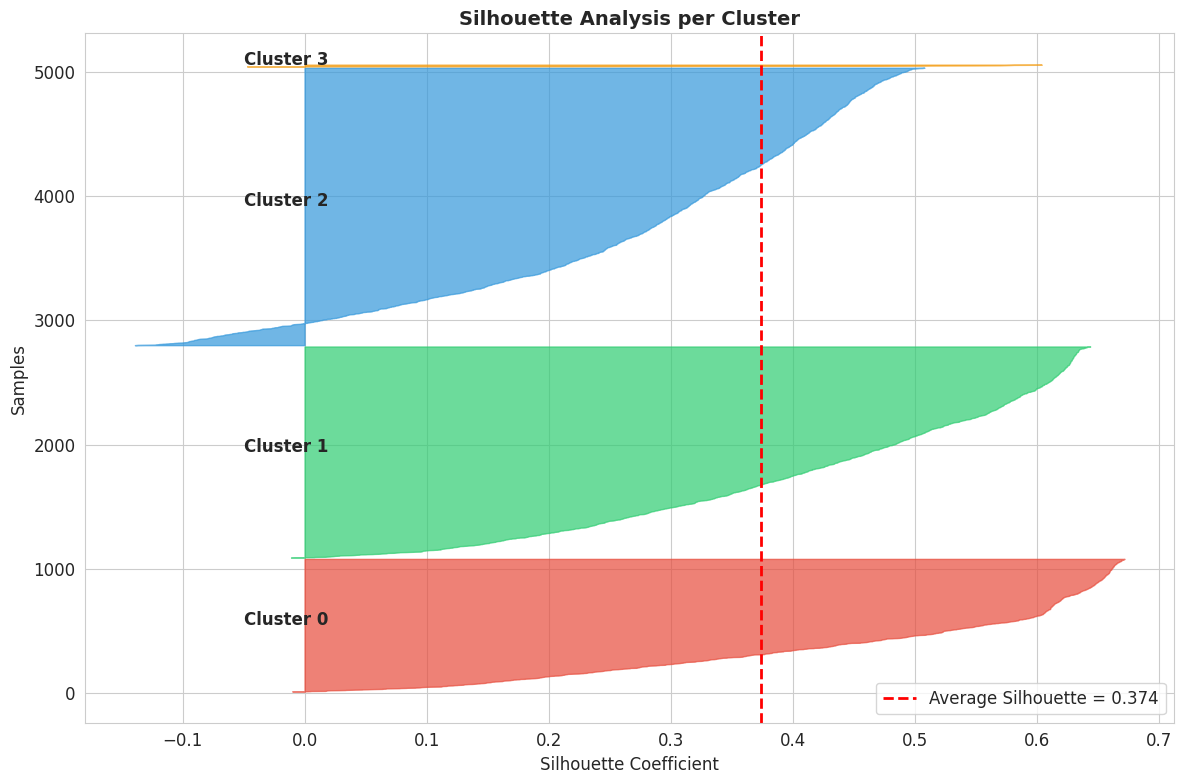

In [12]:
# Silhouette plot per sample
sample_silhouettes = silhouette_samples(X_pca, cluster_labels)

fig, ax = plt.subplots(figsize=(12, 8))

y_lower = 10
for i in range(OPTIMAL_K):
    cluster_sil = sample_silhouettes[cluster_labels == i]
    cluster_sil.sort()

    size = cluster_sil.shape[0]
    y_upper = y_lower + size

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                      alpha=0.7, color=cluster_colors[i])
    ax.text(-0.05, y_lower + 0.5 * size, f'Cluster {i}', fontweight='bold')
    y_lower = y_upper + 10

ax.axvline(x=sil_final, color='red', linestyle='--', linewidth=2,
            label=f'Average Silhouette = {sil_final:.3f}')
ax.set_title('Silhouette Analysis per Cluster', fontsize=14, fontweight='bold')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Samples')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

## 6. Phân tích & Đặt tên Segments

Xem đặc trưng RFM của từng cluster để đặt tên có ý nghĩa kinh doanh.

In [13]:
# Thống kê RFM trung bình theo cluster
segment_stats = customer_data.groupby('segment_id')[RFM_FEATURES].agg(['mean', 'median']).round(2)

# Chỉ lấy mean cho dễ đọc
segment_means = customer_data.groupby('segment_id')[RFM_FEATURES].mean().round(2)

print('=' * 80)
print('📊 ĐẶC TRƯNG TRUNG BÌNH TỪNG CLUSTER')
print('=' * 80)
print(segment_means.to_string())

# Thêm count
segment_means['count'] = customer_data.groupby('segment_id')['segment_id'].count()
print(f'\n  Count per cluster:')
print(segment_means['count'])

📊 ĐẶC TRƯNG TRUNG BÌNH TỪNG CLUSTER
            recency  frequency   monetary  avg_order_value  total_unique_products  avg_days_between_orders  days_since_first_purchase
segment_id                                                                                                                           
0            409.86       2.00     711.24           327.48                  28.24                    24.12                     455.00
1            138.86       2.15     793.29           375.65                  35.88                    23.21                     186.95
2             98.35       8.58    3702.63           393.10                 113.76                   112.58                     485.91
3             19.07     128.73  144841.65          1786.44                 905.00                    10.12                     559.20

  Count per cluster:
segment_id
0    1069
1    1702
2    2237
3      15
Name: count, dtype: int64


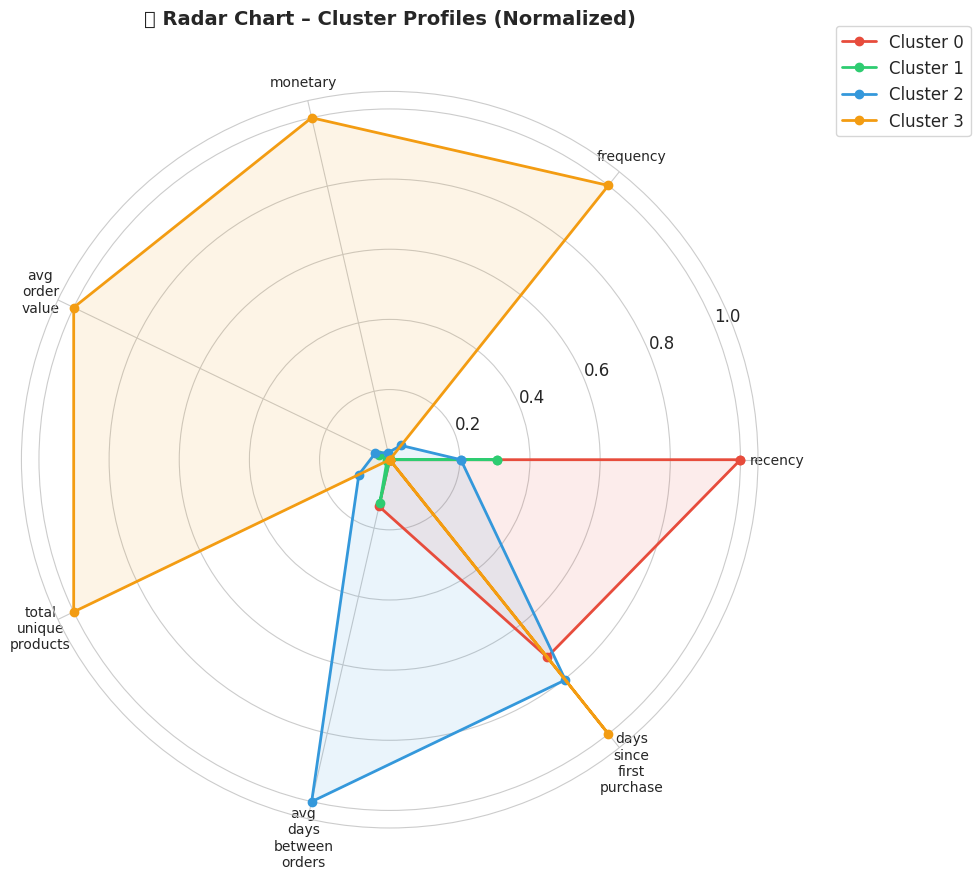

In [14]:
# Radar Chart cho các clusters
# Chuẩn hóa về 0-1 để so sánh
segment_means_norm = segment_means[RFM_FEATURES].copy()
for col in RFM_FEATURES:
    min_val = segment_means_norm[col].min()
    max_val = segment_means_norm[col].max()
    if max_val > min_val:
        segment_means_norm[col] = (segment_means_norm[col] - min_val) / (max_val - min_val)
    else:
        segment_means_norm[col] = 0.5

# Radar chart
categories = RFM_FEATURES
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for i in range(OPTIMAL_K):
    values = segment_means_norm.iloc[i].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {i}',
             color=cluster_colors[i])
    ax.fill(angles, values, alpha=0.1, color=cluster_colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels([f.replace('_', '\n') for f in categories], fontsize=10)
ax.set_title('🕸️ Radar Chart – Cluster Profiles (Normalized)', fontsize=14,
              fontweight='bold', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

In [15]:
# ═══════════════════════════════════════════════════
# ĐẶT TÊN SEGMENTS dựa trên đặc trưng RFM
# ═══════════════════════════════════════════════════
# Logic: sắp xếp clusters theo monetary (chi tiêu) để gán tên
# Bạn có thể tùy chỉnh tên dựa vào kết quả radar chart ở trên

segment_monetary_rank = segment_means['monetary'].sort_values(ascending=False)

SEGMENT_NAMES = {}
segment_labels_ordered = segment_monetary_rank.index.tolist()

name_templates = [
    ('🏆 VIP / Champions', 'Khách chi tiêu cao, mua thường xuyên'),
    ('🌟 Potential / Tiềm năng', 'Khách có tiềm năng phát triển'),
    ('👋 Casual / Vãng lai', 'Khách mua ít, không thường xuyên'),
    ('💤 Hibernating / Ngủ đông', 'Khách lâu không quay lại'),
]

for i, cluster_id in enumerate(segment_labels_ordered):
    if i < len(name_templates):
        SEGMENT_NAMES[cluster_id] = name_templates[i][0]
    else:
        SEGMENT_NAMES[cluster_id] = f'Cluster {cluster_id}'

customer_data['segment_name'] = customer_data['segment_id'].map(SEGMENT_NAMES)

print('=' * 60)
print('🏷️ SEGMENT NAMING')
print('=' * 60)
for cid, name in sorted(SEGMENT_NAMES.items()):
    count = (customer_data['segment_id'] == cid).sum()
    avg_m = segment_means.loc[cid, 'monetary']
    avg_r = segment_means.loc[cid, 'recency']
    avg_f = segment_means.loc[cid, 'frequency']
    print(f'  Cluster {cid} → {name}')
    print(f'    Count: {count:,} | R={avg_r:.0f}d | F={avg_f:.0f} | M=£{avg_m:,.0f}')

🏷️ SEGMENT NAMING
  Cluster 0 → 💤 Hibernating / Ngủ đông
    Count: 1,069 | R=410d | F=2 | M=£711
  Cluster 1 → 👋 Casual / Vãng lai
    Count: 1,702 | R=139d | F=2 | M=£793
  Cluster 2 → 🌟 Potential / Tiềm năng
    Count: 2,237 | R=98d | F=9 | M=£3,703
  Cluster 3 → 🏆 VIP / Champions
    Count: 15 | R=19d | F=129 | M=£144,842


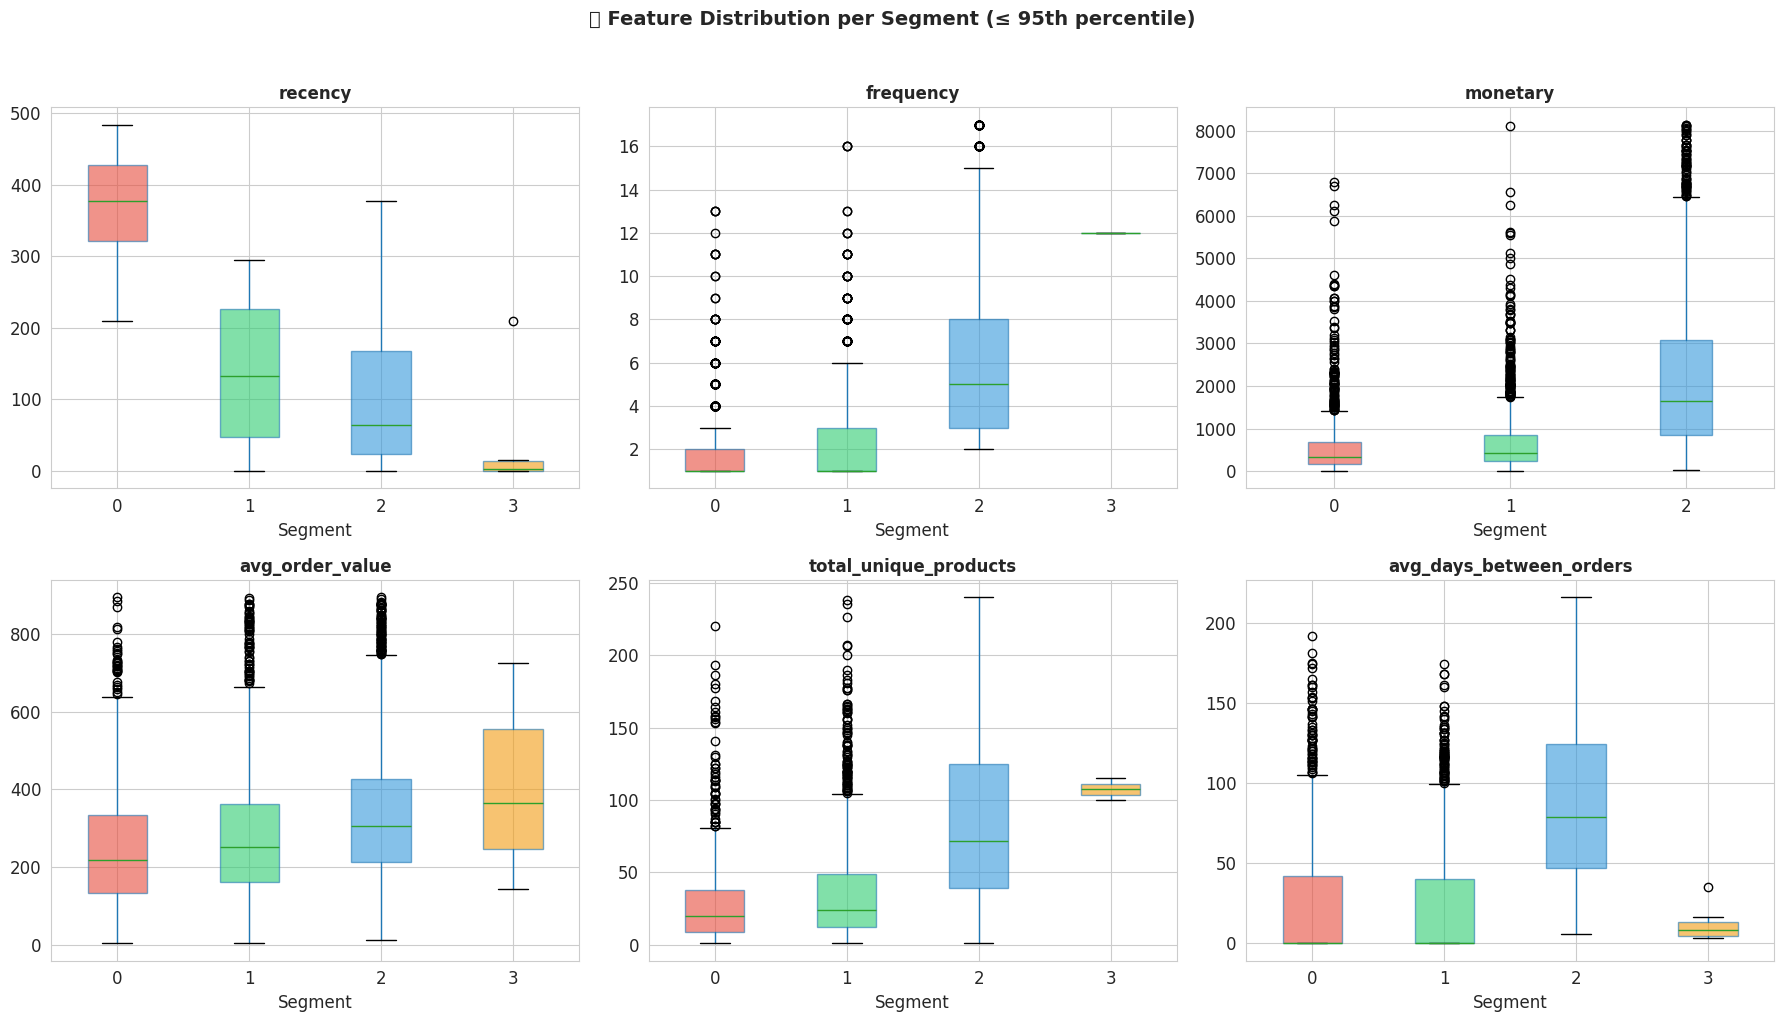

In [16]:
# Box plots so sánh RFM theo segment
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

plot_features = ['recency', 'frequency', 'monetary', 'avg_order_value',
                  'total_unique_products', 'avg_days_between_orders']

for idx, feat in enumerate(plot_features):
    ax = axes[idx]
    # Clip outliers
    q95 = customer_data[feat].quantile(0.95)
    data_clip = customer_data[customer_data[feat] <= q95]

    bp = data_clip.boxplot(column=feat, by='segment_id', ax=ax,
                            patch_artist=True, return_type='dict')
    for i, patch in enumerate(bp[feat]['boxes']):
        patch.set_facecolor(cluster_colors[i])
        patch.set_alpha(0.6)

    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.set_xlabel('Segment')

plt.suptitle('📊 Feature Distribution per Segment (≤ 95th percentile)',
              fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Export Models & Segment Labels

In [17]:
import os
os.makedirs(MODEL_DIR, exist_ok=True)

# 1. Save K-Means model
kmeans_path = f'{MODEL_DIR}/kmeans_model.joblib'
joblib.dump(kmeans_final, kmeans_path)
print(f'✅ K-Means model → {kmeans_path}')

# 2. Save PCA transformer
pca_path = f'{MODEL_DIR}/pca_transformer.joblib'
joblib.dump(pca, pca_path)
print(f'✅ PCA transformer → {pca_path}')

# 3. Save scaler for segmentation
scaler_seg_path = f'{MODEL_DIR}/scaler_segmentation.joblib'
joblib.dump(scaler_seg, scaler_seg_path)
print(f'✅ Scaler (segmentation) → {scaler_seg_path}')

# 4. Save updated customer data (with segment_id)
customer_seg_path = f'{DATA_DIR}/customer_features_with_segments.csv'
customer_data.to_csv(customer_seg_path, index=False)
print(f'✅ Customer data + segments → {customer_seg_path}')

# 5. Save segment config
seg_config = {
    'n_clusters': OPTIMAL_K,
    'rfm_features': RFM_FEATURES,
    'n_pca_components': N_COMPONENTS,
    'pca_explained_variance': pca.explained_variance_ratio_.tolist(),
    'silhouette_score': sil_final,
    'davies_bouldin_score': db_final,
    'segment_names': SEGMENT_NAMES,
    'segment_counts': {int(k): int(v) for k, v in
                        customer_data['segment_id'].value_counts().items()},
}

seg_config_path = f'{MODEL_DIR}/segmentation_config.json'
with open(seg_config_path, 'w', encoding='utf-8') as f:
    json.dump(seg_config, f, indent=2, ensure_ascii=False, default=str)
print(f'✅ Segmentation config → {seg_config_path}')

print('\n' + '=' * 60)
print('🎉 HOÀN TẤT NOTEBOOK 03!')
print('Tiếp tục với Notebook 04: Product Recommendation (KNN)')
print('=' * 60)

✅ K-Means model → /content/drive/MyDrive/ecommerce-ml/models/kmeans_model.joblib
✅ PCA transformer → /content/drive/MyDrive/ecommerce-ml/models/pca_transformer.joblib
✅ Scaler (segmentation) → /content/drive/MyDrive/ecommerce-ml/models/scaler_segmentation.joblib
✅ Customer data + segments → /content/drive/MyDrive/ecommerce-ml/data/customer_features_with_segments.csv
✅ Segmentation config → /content/drive/MyDrive/ecommerce-ml/models/segmentation_config.json

🎉 HOÀN TẤT NOTEBOOK 03!
Tiếp tục với Notebook 04: Product Recommendation (KNN)
